In [1]:
import pandas as pd
import numpy as np
from gensim.models import Word2Vec
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, classification_report
import pickle
from nltk.tokenize import word_tokenize
import nltk

# Download the NLTK punkt tokenizer (if not already downloaded)
nltk.download('punkt')

# Load your preprocessed dataset
data_path = r"C:\Users\PC\OneDrive\Desktop\your_preprocessed_data.xlsx"  # Use raw string for the file path
data = pd.read_excel(data_path)

# Replace with the actual column names in your dataset
text_column = 'cleaned_text'  # Column containing the cleaned text data
target_column = 'encoded_class'  # Column containing the target labels

# Ensure no missing values in the text column
data[text_column] = data[text_column].fillna("missing")

# Step 1: Tokenize the text data
print("Tokenizing text data...")
tokenized_texts = [word_tokenize(text.lower()) for text in data[text_column]]

# Step 2: Train a Word2Vec model
print("Training Word2Vec model...")
word2vec_model = Word2Vec(sentences=tokenized_texts, vector_size=100, window=5, min_count=1, workers=4)

# Step 3: Convert text data to numeric features using Word2Vec
print("Converting text data to numeric features...")
def text_to_avg_vector(tokens):
    vectors = [word2vec_model.wv[word] for word in tokens if word in word2vec_model.wv]
    if vectors:
        return np.mean(vectors, axis=0)
    else:
        return np.zeros(word2vec_model.vector_size)

X = np.array([text_to_avg_vector(tokens) for tokens in tokenized_texts])
y = data[target_column]  # Target labels

# Step 4: Split the dataset into training and testing sets
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

# Step 5: Initialize and train the Logistic Regression model
print("Training Logistic Regression model...")
logistic_model = LogisticRegression(max_iter=1000, random_state=42)
logistic_model.fit(X_train, y_train)

# Step 6: Save the trained Logistic Regression model
model_path = r"C:\Users\PC\Downloads\Logistic_model.pkl"  # File path to save the model
with open(model_path, 'wb') as f:
    pickle.dump(logistic_model, f)
print(f"Trained Logistic Regression model saved to {model_path}")

# Step 7: Evaluate the Logistic Regression model
y_pred_lr = logistic_model.predict(X_test)

# Calculate metrics
accuracy = accuracy_score(y_test, y_pred_lr)
precision = precision_score(y_test, y_pred_lr, average='weighted')
recall = recall_score(y_test, y_pred_lr, average='weighted')
f1 = f1_score(y_test, y_pred_lr, average='weighted')

# Print metrics in the desired format
print(f"Logistic Regression Accuracy: {accuracy * 100:.2f}%")
print(f"Logistic Regression Precision: {precision * 100:.2f}%")
print(f"Logistic Regression Recall: {recall * 100:.2f}%")
print(f"Logistic Regression F1 Score: {f1 * 100:.2f}%")

# Print detailed classification report (optional)
print("\nDetailed Classification Report:")
print(classification_report(y_test, y_pred_lr))


[nltk_data] Downloading package punkt to
[nltk_data]     C:\Users\PC\AppData\Roaming\nltk_data...
[nltk_data]   Package punkt is already up-to-date!


Tokenizing text data...
Training Word2Vec model...
Converting text data to numeric features...
Training Logistic Regression model...
Trained Logistic Regression model saved to C:\Users\PC\Downloads\Logistic_model.pkl
Logistic Regression Accuracy: 91.28%
Logistic Regression Precision: 91.33%
Logistic Regression Recall: 91.28%
Logistic Regression F1 Score: 91.28%

Detailed Classification Report:
              precision    recall  f1-score   support

           0       0.93      0.90      0.91     23238
           1       0.90      0.93      0.91     23171

    accuracy                           0.91     46409
   macro avg       0.91      0.91      0.91     46409
weighted avg       0.91      0.91      0.91     46409



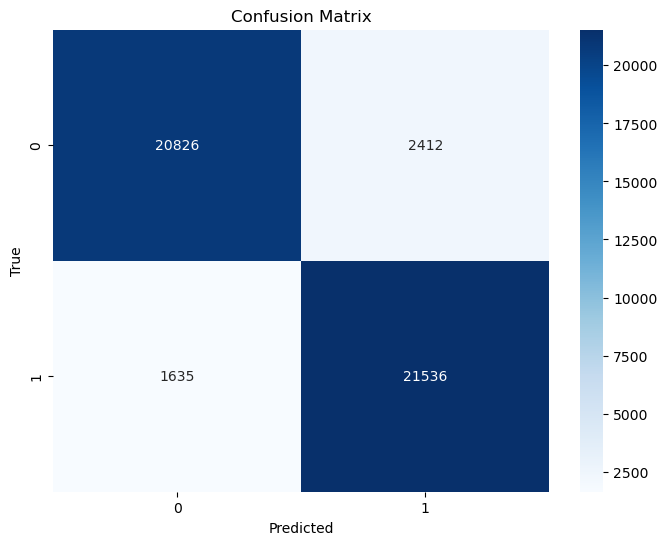

In [2]:
from sklearn.metrics import confusion_matrix
import seaborn as sns
import matplotlib.pyplot as plt

# Step 8: Generate and display the confusion matrix
conf_matrix = confusion_matrix(y_test, y_pred_lr)

# Plot confusion matrix using Seaborn heatmap
plt.figure(figsize=(8, 6))
sns.heatmap(conf_matrix, annot=True, fmt='d', cmap='Blues', xticklabels=np.unique(y), yticklabels=np.unique(y))
plt.title("Confusion Matrix")
plt.xlabel("Predicted")
plt.ylabel("True")
plt.show()


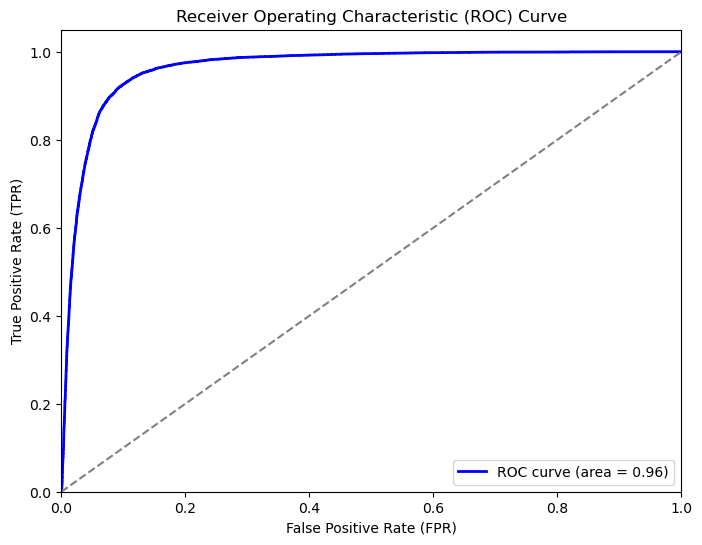

In [3]:
from sklearn.metrics import roc_curve, auc
import matplotlib.pyplot as plt

# Step: Compute ROC curve and AUC (Area Under Curve)
fpr, tpr, thresholds = roc_curve(y_test, logistic_model.predict_proba(X_test)[:, 1], pos_label=1)
roc_auc = auc(fpr, tpr)

# Plot ROC curve
plt.figure(figsize=(8, 6))
plt.plot(fpr, tpr, color='blue', lw=2, label=f'ROC curve (area = {roc_auc:.2f})')
plt.plot([0, 1], [0, 1], color='gray', linestyle='--')  # Diagonal line (no skill)
plt.xlim([0.0, 1.0])
plt.ylim([0.0, 1.05])
plt.xlabel('False Positive Rate (FPR)')
plt.ylabel('True Positive Rate (TPR)')
plt.title('Receiver Operating Characteristic (ROC) Curve')
plt.legend(loc="lower right")
plt.show()


Training Logistic Regression model...
Logistic Regression MAE: 0.0872, MSE: 0.0872, RMSE: 0.2953


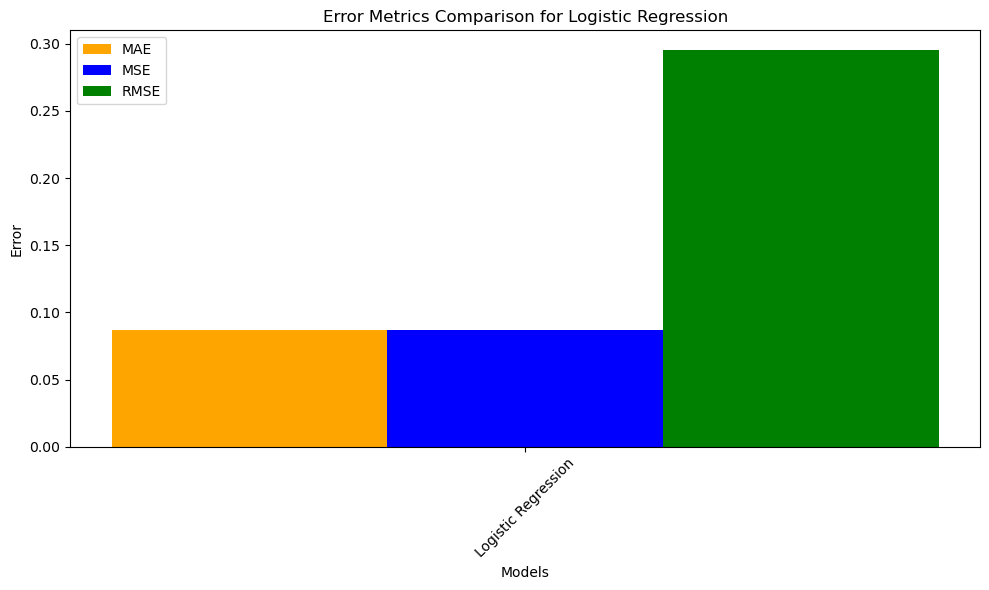

In [5]:
from sklearn.metrics import mean_absolute_error, mean_squared_error
import numpy as np
import matplotlib.pyplot as plt
from sklearn.linear_model import LogisticRegression

# Dictionary to store error metrics
error_metrics = {}

# Assuming you already have X_train, X_test, y_train, and y_test ready
# Initialize and train the Logistic Regression model
print("Training Logistic Regression model...")
logistic_model = LogisticRegression(max_iter=1000, random_state=42)
logistic_model.fit(X_train, y_train)

# Predict on the test set
y_pred_lr = logistic_model.predict(X_test)

# Calculate error metrics
mae_lr = mean_absolute_error(y_test, y_pred_lr)
mse_lr = mean_squared_error(y_test, y_pred_lr)
rmse_lr = np.sqrt(mse_lr)

# Store error metrics
error_metrics["Logistic Regression"] = {"MAE": mae_lr, "MSE": mse_lr, "RMSE": rmse_lr}

# Print metrics
print(f"Logistic Regression MAE: {mae_lr:.4f}, MSE: {mse_lr:.4f}, RMSE: {rmse_lr:.4f}")

# Plot the error metrics
mae_values = [metrics["MAE"] for metrics in error_metrics.values()]
mse_values = [metrics["MSE"] for metrics in error_metrics.values()]
rmse_values = [metrics["RMSE"] for metrics in error_metrics.values()]
model_names = list(error_metrics.keys())

x = np.arange(len(model_names))
width = 0.25

plt.figure(figsize=(10, 6))
plt.bar(x - width, mae_values, width, label='MAE', color='orange')
plt.bar(x, mse_values, width, label='MSE', color='blue')
plt.bar(x + width, rmse_values, width, label='RMSE', color='green')

plt.xlabel('Models')
plt.ylabel('Error')
plt.title('Error Metrics Comparison for Logistic Regression')
plt.xticks(x, model_names, rotation=45)
plt.legend()
plt.tight_layout()
plt.show()


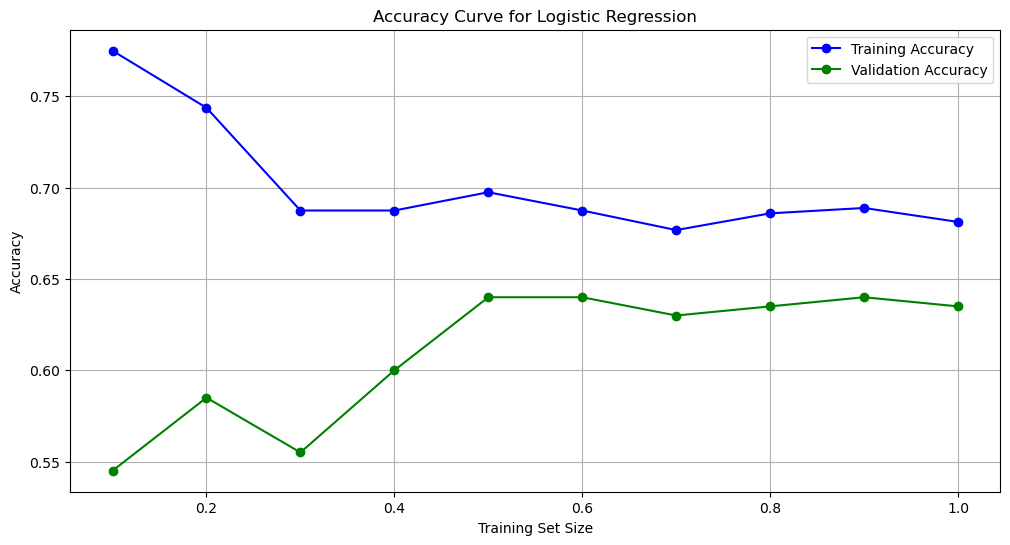

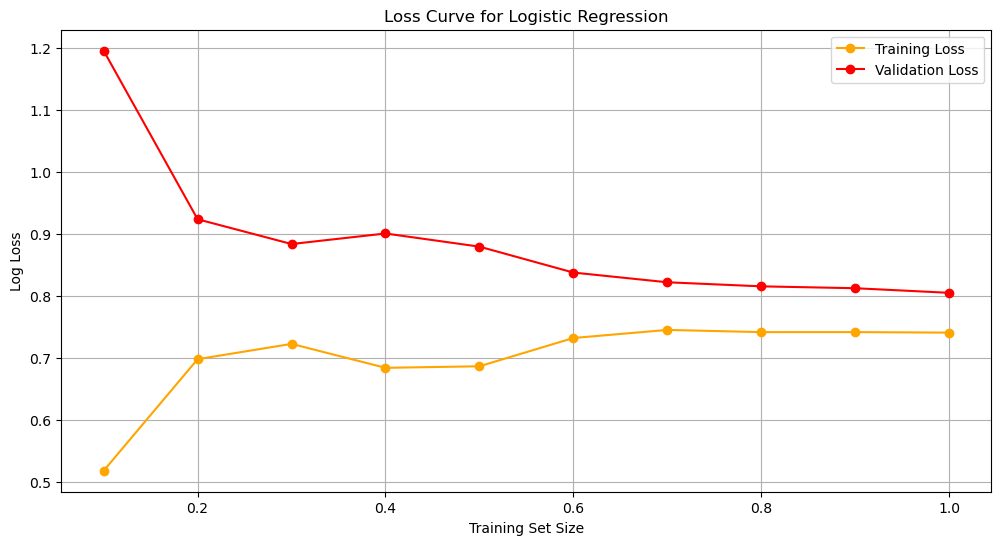

In [4]:
import numpy as np
import matplotlib.pyplot as plt
from sklearn.metrics import log_loss, accuracy_score
from sklearn.linear_model import LogisticRegression

# Initialize Logistic Regression model
logistic_model = LogisticRegression(max_iter=1000, random_state=42)

# Arrays to store accuracy and loss
train_sizes = np.linspace(0.1, 1.0, 10)  # Progressively larger portions of the training data
train_accuracies = []
val_accuracies = []
train_losses = []
val_losses = []

# Loop through different training data sizes
for size in train_sizes:
    # Use a portion of the training data
    subset_size = int(size * len(X_train))
    X_train_subset = X_train[:subset_size]
    y_train_subset = y_train[:subset_size]
    
    # Train the model on the subset
    logistic_model.fit(X_train_subset, y_train_subset)
    
    # Predict on the training subset and validation set
    y_train_pred = logistic_model.predict(X_train_subset)
    y_val_pred = logistic_model.predict(X_test)
    
    # Predict probabilities for loss calculation
    y_train_proba = logistic_model.predict_proba(X_train_subset)
    y_val_proba = logistic_model.predict_proba(X_test)
    
    # Calculate accuracy
    train_accuracies.append(accuracy_score(y_train_subset, y_train_pred))
    val_accuracies.append(accuracy_score(y_test, y_val_pred))
    
    # Calculate log loss
    train_losses.append(log_loss(y_train_subset, y_train_proba))
    val_losses.append(log_loss(y_test, y_val_proba))

# Plot Accuracy Curve
plt.figure(figsize=(12, 6))
plt.plot(train_sizes, train_accuracies, label='Training Accuracy', marker='o', color='blue')
plt.plot(train_sizes, val_accuracies, label='Validation Accuracy', marker='o', color='green')
plt.title('Accuracy Curve for Logistic Regression')
plt.xlabel('Training Set Size')
plt.ylabel('Accuracy')
plt.legend(loc='best')
plt.grid()
plt.show()

# Plot Loss Curve
plt.figure(figsize=(12, 6))
plt.plot(train_sizes, train_losses, label='Training Loss', marker='o', color='orange')
plt.plot(train_sizes, val_losses, label='Validation Loss', marker='o', color='red')
plt.title('Loss Curve for Logistic Regression')
plt.xlabel('Training Set Size')
plt.ylabel('Log Loss')
plt.legend(loc='best')
plt.grid()
plt.show()
